### Notebook used to visualize the generated datasets

In [2]:
%cd C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM

C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM


Visualizing 1 samples from flumy_batch_0000.h5...


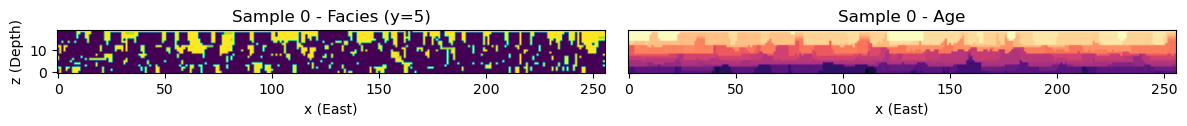

In [4]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

def visualize_h5_batch(file_path, max_samples=5, slice_axis='y', slice_idx=None):
    """
    Visualizes samples from a single HDF5 batch file.
    
    Args:
        file_path (str): Path to the .h5 file.
        max_samples (int): Maximum number of samples to display.
        slice_axis (str): 'x', 'y', or 'z' (direction to slice through).
        slice_idx (int): Index to slice at. If None, uses the middle of the volume.
    """
    if not os.path.exists(file_path):
        print(f"Error: File {file_path} not found.")
        return

    with h5py.File(file_path, 'r') as f:
        # 1. Get total available samples in this file
        total_in_file = f['facies'].shape[0]
        n_show = min(total_in_file, max_samples)
        
        print(f"Visualizing {n_show} samples from {os.path.basename(file_path)}...")
        
        # 2. Setup Figure
        fig, ax = plt.subplots(nrows=n_show, ncols=2, figsize=(12, 4 * n_show))
        
        # Handle single sample case (matplotlib squeeze behavior)
        if n_show == 1:
            ax = np.expand_dims(ax, axis=0)

        # 3. Loop through the samples inside the HDF5
        for i in range(n_show):
            # Load the 3D volume for the i-th sample
            # Shape is (nx, ny, nz)
            fac_vol = f['facies'][i]
            age_vol = f['age'][i]
            
            # 4. Determine Slicing Logic
            nx, ny, nz = fac_vol.shape
            
            if slice_axis == 'z': # Map View (Top-down)
                idx = slice_idx if slice_idx is not None else nz // 2
                slc_fac = fac_vol[:, :, idx]
                slc_age = age_vol[:, :, idx]
                ylabel = "y (North)"
                xlabel = "x (East)"
                aspect = 'equal'
                
            elif slice_axis == 'y': # Cross-section (Side view along Y)
                idx = slice_idx if slice_idx is not None else ny // 2
                # We transpose (.T) to put Z on vertical axis for geological view
                slc_fac = fac_vol[:, idx, :].T 
                slc_age = age_vol[:, idx, :].T
                ylabel = "z (Depth)"
                xlabel = "x (East)"
                aspect = 'equal' # Often better for Z-exaggeration
                
            elif slice_axis == 'x': # Cross-section (Side view along X)
                idx = slice_idx if slice_idx is not None else nx // 2
                slc_fac = fac_vol[idx, :, :].T
                slc_age = age_vol[idx, :, :].T
                ylabel = "z (Depth)"
                xlabel = "y (North)"
                aspect = 'auto'

            # 5. Plotting
            # -- Column 1: Facies --
            ax[i, 0].imshow(slc_fac, origin='lower', cmap='viridis', aspect=aspect)
            ax[i, 0].set_title(f"Sample {i} - Facies ({slice_axis}={idx})")
            ax[i, 0].set_ylabel(ylabel)
            ax[i, 0].set_xlabel(xlabel)

            # -- Column 2: Age --
            ax[i, 1].imshow(slc_age, origin='lower', cmap='magma', aspect=aspect)
            ax[i, 1].set_title(f"Sample {i} - Age")
            ax[i, 1].set_xlabel(xlabel)
            # Remove y-ticks for the second plot to clean up look
            ax[i, 1].set_yticks([])

    plt.tight_layout()
    plt.show()

# --- Usage Example ---
# Point this to one of your generated batch files
file_path = os.path.join("data", "datasets", "training")

filename = os.path.join("flumy_batch_0000.h5")
visualize_h5_batch(os.path.join(file_path, filename), max_samples=3, slice_axis='y', slice_idx=5)

# View 3 samples, cutting through the Y-axis (Cross-section) at index 50
# for filename in os.listdir(file_path):
#     if filename.endswith(".h5"):
#         visualize_h5_batch(os.path.join(file_path, filename), max_samples=3, slice_axis='z', slice_idx=5)

NameError: name 'unique_vals' is not defined

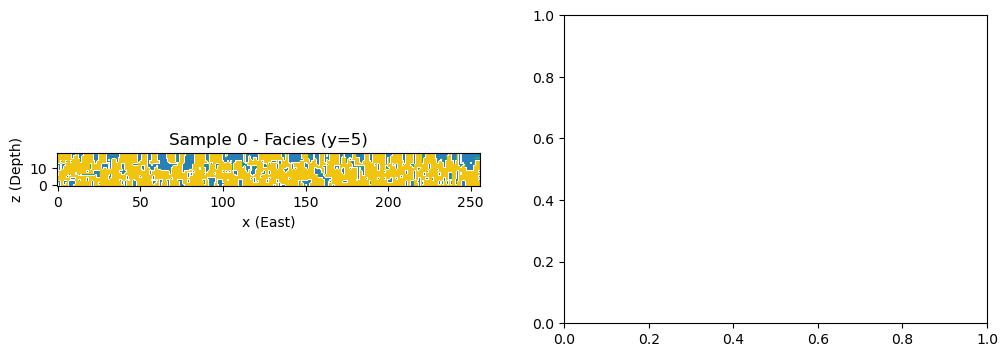

In [6]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

def visualize_h5_batch(file_path, max_samples=5, slice_axis='y', slice_idx=None):
    if not os.path.exists(file_path):
        print(f"Error: File {file_path} not found.")
        return

    # --- 1. Define Custom Facies Colors ---
    # Mapping: 1 -> Yellow (Channel), 7 -> Green (Overbank), 8 -> Blue (Background)
    # You can change these hex codes/names to whatever you prefer!
    facies_colors = {
        1: "#f1c40f", # Yellow
        7: "#27ae60", # Green
        8: "#2980b9"  # Blue
    }
    
    # 1. Define colors for our specific facies
    # We add a neutral color (like white) for the gap between 1 and 7
    # Order: [Color for 1, Color for gap 2-6, Color for 7, Color for 8]
    colors = [facies_colors[1], "#ffffff", facies_colors[7], facies_colors[8]]
    
    cmap_facies = ListedColormap(colors)
    
    # 2. Define the boundaries (5 boundaries = 4 bins)
    # Bin 1: 0.5-1.5 | Bin 2: 1.5-6.5 | Bin 3: 6.5-7.5 | Bin 4: 7.5-8.5
    boundaries = [0.5, 1.5, 6.5, 7.5, 8.5]
    norm_facies = BoundaryNorm(boundaries, cmap_facies.N)

    with h5py.File(file_path, 'r') as f:
        total_in_file = f['facies'].shape[0]
        n_show = min(total_in_file, max_samples)
        
        fig, ax = plt.subplots(nrows=n_show, ncols=2, figsize=(12, 4 * n_show))
        if n_show == 1:
            ax = np.expand_dims(ax, axis=0)

        for i in range(n_show):
            fac_vol = f['facies'][i]
            age_vol = f['age'][i]
            nx, ny, nz = fac_vol.shape
            
            # --- Slicing Logic ---
            if slice_axis == 'z':
                idx = slice_idx if slice_idx is not None else nz // 2
                slc_fac, slc_age = fac_vol[:, :, idx], age_vol[:, :, idx]
                ylabel, xlabel, aspect = "y (North)", "x (East)", 'equal'
            elif slice_axis == 'y':
                idx = slice_idx if slice_idx is not None else ny // 2
                slc_fac, slc_age = fac_vol[:, idx, :].T, age_vol[:, idx, :].T
                ylabel, xlabel, aspect = "z (Depth)", "x (East)", 'equal'
            elif slice_axis == 'x':
                idx = slice_idx if slice_idx is not None else nx // 2
                slc_fac, slc_age = fac_vol[idx, :, :].T, age_vol[idx, :, :].T
                ylabel, xlabel, aspect = "z (Depth)", "y (North)", 'auto'

            # --- Plotting ---
            # Column 1: Facies (Using CUSTOM CMAP)
            im_fac = ax[i, 0].imshow(slc_fac, origin='lower', cmap=cmap_facies, 
                                     norm=norm_facies, aspect=aspect)
            ax[i, 0].set_title(f"Sample {i} - Facies ({slice_axis}={idx})")
            ax[i, 0].set_ylabel(ylabel)
            ax[i, 0].set_xlabel(xlabel)
            
            # Optional: Add a legend to the first sample
            if i == 0:
                from matplotlib.patches import Patch
                legend_elements = [Patch(facecolor=facies_colors[v], label=f'Facies {v}') for v in unique_vals]
                ax[i, 0].legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.1, 1.1))

            # Column 2: Age
            ax[i, 1].imshow(slc_age, origin='lower', cmap='magma', aspect=aspect)
            ax[i, 1].set_title(f"Sample {i} - Age")
            ax[i, 1].set_xlabel(xlabel)
            ax[i, 1].set_yticks([])

    plt.tight_layout()
    plt.show()

# --- Usage Example ---
# Point this to one of your generated batch files
file_path = os.path.join("data", "datasets", "training")

filename = os.path.join("flumy_batch_0000.h5")
visualize_h5_batch(os.path.join(file_path, filename), max_samples=3, slice_axis='y', slice_idx=5)

Detected One-Hot encoding. Collapsing channels...


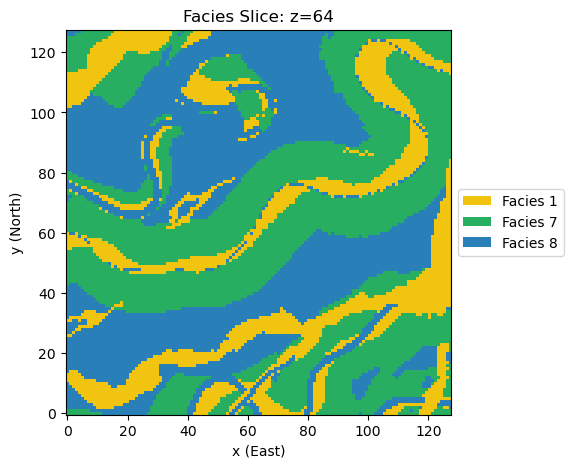

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

def visualize_facies_npz(file_path, slice_axis='z', slice_idx=None):
    if not os.path.exists(file_path):
        print(f"Error: File {file_path} not found.")
        return

    # --- 1. Load and Decode ---
    data = np.load(file_path)
    fac_data = data['facies']

    # If it's One-Hot Encoded (Channels, Z, Y, X), collapse it
    # categories = [1, 7, 8]
    if fac_data.ndim == 4:
        print("Detected One-Hot encoding. Collapsing channels...")
        # argmax gives 0, 1, 2. We map these back to 1, 7, 8
        idx_map = {0: 1, 1: 7, 2: 8}
        collapsed = np.argmax(fac_data, axis=0)
        fac_vol = np.vectorize(idx_map.get)(collapsed)
    else:
        fac_vol = fac_data

    # --- 2. Slicing ---
    # --- 2. Slicing ---
    nz, ny, nx = fac_vol.shape
    if slice_axis == 'z':
        # Map view: y on vertical, x on horizontal
        idx = slice_idx if slice_idx is not None else nz // 2
        slc = fac_vol[idx, :, :]
        ylabel, xlabel = "y (North)", "x (East)"
    elif slice_axis == 'y':
        # XZ Cross-section: z on vertical, x on horizontal
        idx = slice_idx if slice_idx is not None else ny // 2
        slc = fac_vol[:, idx, :]  # Removed .T
        ylabel, xlabel = "z (Depth/Elevation)", "x (East)"
    else: # slice_axis == 'x'
        # YZ Cross-section: z on vertical, y on horizontal
        idx = slice_idx if slice_idx is not None else nx // 2
        slc = fac_vol[:, :, idx] # Removed .T
        ylabel, xlabel = "z (Depth/Elevation)", "y (North)"

    # --- 3. Colors & Plot ---
    facies_colors = {1: "#f1c40f", 7: "#27ae60", 8: "#2980b9"}
    colors = [facies_colors[1], "#ffffff", facies_colors[7], facies_colors[8]]
    cmap = ListedColormap(colors)
    norm = BoundaryNorm([0.5, 1.5, 6.5, 7.5, 8.5], cmap.N)

    plt.figure(figsize=(10, 5))
    plt.imshow(slc, origin='lower', cmap=cmap, norm=norm, aspect='equal')
    
    # Legend
    legend_elements = [Patch(facecolor=facies_colors[v], label=f'Facies {v}') 
                       for v in np.unique(slc) if v in facies_colors]
    plt.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5))
    
    plt.title(f"Facies Slice: {slice_axis}={idx}")
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    plt.show()

# --- Usage ---
base = os.path.join(os.getcwd(), "test_outputs")
visualize_facies_npz(os.path.join(base, "sample_43.npz"), slice_axis='z')